*imports*

In [17]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

In [ ]:
project paths

In [18]:
BASE_DIR = Path(r"D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training")

ATTACK_DIR = BASE_DIR / "attack"
NORMAL_DIR = BASE_DIR / "normal"

DATASETS_DIR = BASE_DIR / "datasets"
RAW_COMBINED_DIR = DATASETS_DIR / "raw_combined"
PROCESSED_DIR = DATASETS_DIR / "processed"
FEATURES_DIR = DATASETS_DIR / "feature_sets"

MODELS_DIR = BASE_DIR / "models"
OUTPUTS_DIR = BASE_DIR / "outputs"

RAW_COMBINED_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

print("Base folder:", BASE_DIR)
print("Attack folder exists:", ATTACK_DIR.exists())
print("Normal folder exists:", NORMAL_DIR.exists())

Base folder: D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training
Attack folder exists: True
Normal folder exists: True


In [19]:
attack_files = sorted(ATTACK_DIR.glob("*.csv"))
normal_files = sorted(NORMAL_DIR.glob("*.csv"))

print("Attack CSV files:")
for f in attack_files:
    print(" -", f.name)

print("\nNormal CSV files:")
for f in normal_files:
    print(" -", f.name)

Attack CSV files:
 - attack_ftp_bruteforce.csv
 - attack_hping3.csv
 - attack_scan_nmap.csv
 - attack_slowloris.csv
 - attack_ssh_bruteforce.csv
 - attack_telnet_bruteforce.csv

Normal CSV files:
 - normal_ftp_transfer.csv
 - normal_http_windows.csv
 - normal_https_windows.csv
 - normal_mixed_realistic.csv
 - normal_ssh_legit.csv


In [ ]:
/helper function to load CSV and label it

In [20]:
def load_csv_files(file_list, label_value, class_name):
    dfs = []
    encodings_to_try = ["utf-8", "utf-8-sig", "cp1252", "latin1"]

    for file_path in file_list:
        loaded = False

        for enc in encodings_to_try:
            try:
                df = pd.read_csv(file_path, low_memory=False, encoding=enc)
                df["label"] = label_value
                df["traffic_type"] = class_name
                df["source_file"] = file_path.name
                dfs.append(df)
                print(f"Loaded: {file_path.name} with encoding={enc} -> shape {df.shape}")
                loaded = True
                break
            except Exception as e:
                last_error = e

        if not loaded:
            print(f"Failed to load {file_path.name}: {last_error}")

    if dfs:
        return pd.concat(dfs, ignore_index=True)
    else:
        return pd.DataFrame()

In [ ]:
load attack and normal datasets

In [21]:
attack_df = load_csv_files(attack_files, 1, "attack")
normal_df = load_csv_files(normal_files, 0, "normal")

print("\nAttack shape:", attack_df.shape)
print("Normal shape:", normal_df.shape)

Loaded: attack_ftp_bruteforce.csv with encoding=utf-8 -> shape (2179, 15)
Loaded: attack_hping3.csv with encoding=utf-8 -> shape (365224, 15)
Loaded: attack_scan_nmap.csv with encoding=utf-8 -> shape (135071, 15)
Loaded: attack_slowloris.csv with encoding=utf-8 -> shape (7148, 15)
Loaded: attack_ssh_bruteforce.csv with encoding=utf-8 -> shape (2009, 15)
Loaded: attack_telnet_bruteforce.csv with encoding=cp1252 -> shape (3352, 15)
Loaded: normal_ftp_transfer.csv with encoding=utf-8 -> shape (670, 15)
Loaded: normal_http_windows.csv with encoding=utf-8 -> shape (2874, 15)
Loaded: normal_https_windows.csv with encoding=utf-8 -> shape (500, 15)
Loaded: normal_mixed_realistic.csv with encoding=cp1252 -> shape (8089, 15)
Loaded: normal_ssh_legit.csv with encoding=utf-8 -> shape (2558, 15)

Attack shape: (514983, 15)
Normal shape: (14691, 15)


In [22]:
print("\nAttack source file distribution:")
print(attack_df["source_file"].value_counts())

print("\nNormal source file distribution:")
print(normal_df["source_file"].value_counts())


Attack source file distribution:
source_file
attack_hping3.csv               365224
attack_scan_nmap.csv            135071
attack_slowloris.csv              7148
attack_telnet_bruteforce.csv      3352
attack_ftp_bruteforce.csv         2179
attack_ssh_bruteforce.csv         2009
Name: count, dtype: int64

Normal source file distribution:
source_file
normal_mixed_realistic.csv    8089
normal_http_windows.csv       2874
normal_ssh_legit.csv          2558
normal_ftp_transfer.csv        670
normal_https_windows.csv       500
Name: count, dtype: int64


In [31]:
combined_df = pd.concat([attack_df, normal_df], ignore_index=True)

print("Combined shape:", combined_df.shape)
print(combined_df["traffic_type"].value_counts())

Combined shape: (529674, 15)
traffic_type
attack    514983
normal     14691
Name: count, dtype: int64


In [32]:
def clean_column_name(col):
    col = str(col).strip().lower()
    col = col.replace(" ", "_")
    col = col.replace(".", "_")
    col = col.replace("/", "_")
    col = col.replace("-", "_")
    col = col.replace("(", "")
    col = col.replace(")", "")
    return col

combined_df.columns = [clean_column_name(c) for c in combined_df.columns]

print(combined_df.columns.tolist())

['no_', 'time', 'source', 'destination', 'protocol', 'source_port', 'length', 'tcp_flags', 'dst_port', 'stream_id', 'delta_time', 'info', 'label', 'traffic_type', 'source_file']


In [33]:
for i, c in enumerate(combined_df.columns):
    print(i, c)

0 no_
1 time
2 source
3 destination
4 protocol
5 source_port
6 length
7 tcp_flags
8 dst_port
9 stream_id
10 delta_time
11 info
12 label
13 traffic_type
14 source_file


In [34]:
combined_df.to_csv(
    BASE_DIR / "datasets/raw_combined/master_dataset_full_raw.csv",
    index=False
)

print("Saved raw full dataset")

Saved raw full dataset


In [35]:
grouped = {}

for file_name in combined_df["source_file"].unique():
    grouped[file_name] = combined_df[
        combined_df["source_file"] == file_name
    ].copy()

for k,v in grouped.items():
    print(k, v.shape)

attack_ftp_bruteforce.csv (2179, 15)
attack_hping3.csv (365224, 15)
attack_scan_nmap.csv (135071, 15)
attack_slowloris.csv (7148, 15)
attack_ssh_bruteforce.csv (2009, 15)
attack_telnet_bruteforce.csv (3352, 15)
normal_ftp_transfer.csv (670, 15)
normal_http_windows.csv (2874, 15)
normal_https_windows.csv (500, 15)
normal_mixed_realistic.csv (8089, 15)
normal_ssh_legit.csv (2558, 15)


In [38]:
balanced_parts = []

# Keep all normal
for file_name in combined_df["source_file"].unique():
    if "normal_" in file_name:
        balanced_parts.append(grouped[file_name])

# Keep all smaller attacks
keep_full = [
    "attack_ftp_bruteforce.csv",
    "attack_ssh_bruteforce.csv",
    "attack_telnet_bruteforce.csv",
    "attack_slowloris.csv"
]

for fname in keep_full:
    if fname in grouped:
        balanced_parts.append(grouped[fname])

# Downsample huge attacks
if "attack_hping3.csv" in grouped:
    balanced_parts.append(
        grouped["attack_hping3.csv"].sample(
            n=12000,
            random_state=42
        )
    )

if "attack_scan_nmap.csv" in grouped:
    balanced_parts.append(
        grouped["attack_scan_nmap.csv"].sample(
            n=12000,
            random_state=42
        )
    )

In [39]:
balanced_df = pd.concat(balanced_parts, ignore_index=True)

print("Balanced shape:", balanced_df.shape)

print("\nTraffic Type:")
print(balanced_df["traffic_type"].value_counts())

print("\nBy Source File:")
print(balanced_df["source_file"].value_counts())

Balanced shape: (53379, 15)

Traffic Type:
traffic_type
attack    38688
normal    14691
Name: count, dtype: int64

By Source File:
source_file
attack_hping3.csv               12000
attack_scan_nmap.csv            12000
normal_mixed_realistic.csv       8089
attack_slowloris.csv             7148
attack_telnet_bruteforce.csv     3352
normal_http_windows.csv          2874
normal_ssh_legit.csv             2558
attack_ftp_bruteforce.csv        2179
attack_ssh_bruteforce.csv        2009
normal_ftp_transfer.csv           670
normal_https_windows.csv          500
Name: count, dtype: int64


In [40]:
balanced_df.to_csv(
    BASE_DIR / "datasets/processed/master_dataset_balanced_v1.csv",
    index=False
)

print("Saved balanced dataset")

Saved balanced dataset


In [41]:
for i, c in enumerate(combined_df.columns):
    print(i, c)

0 no_
1 time
2 source
3 destination
4 protocol
5 source_port
6 length
7 tcp_flags
8 dst_port
9 stream_id
10 delta_time
11 info
12 label
13 traffic_type
14 source_file


In [42]:
ml_df = balanced_df.copy()

In [43]:
drop_cols = [
    "no_",
    "source",
    "destination",
    "traffic_type",
    "source_file"
]

ml_df = ml_df.drop(columns=drop_cols, errors="ignore")

print(ml_df.columns.tolist())

['time', 'protocol', 'source_port', 'length', 'tcp_flags', 'dst_port', 'stream_id', 'delta_time', 'info', 'label']


In [44]:
ml_df = ml_df.fillna("unknown")

In [45]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

cat_cols = ["protocol", "tcp_flags", "info"]

for col in cat_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))
    encoders[col] = le

print("Encoded categorical columns")

Encoded categorical columns


In [46]:
num_cols = [
    "time",
    "source_port",
    "length",
    "dst_port",
    "stream_id",
    "delta_time"
]

for col in num_cols:
    ml_df[col] = pd.to_numeric(ml_df[col], errors="coerce")

ml_df = ml_df.fillna(0)

In [47]:
X = ml_df.drop(columns=["label"])
y = ml_df["label"]

print(X.shape, y.shape)

(53379, 9) (53379,)


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(42703, 9) (10676, 9)


In [49]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
pred = rf.predict(X_test)

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, pred))
print()
print(classification_report(y_test, pred))

[[2926   12]
 [  48 7690]]

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2938
           1       1.00      0.99      1.00      7738

    accuracy                           0.99     10676
   macro avg       0.99      0.99      0.99     10676
weighted avg       0.99      0.99      0.99     10676



In [52]:
imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(imp)

time           0.442193
stream_id      0.227640
delta_time     0.137465
length         0.085330
info           0.027314
tcp_flags      0.026828
dst_port       0.021434
protocol       0.018365
source_port    0.013430
dtype: float64


In [53]:
X2 = X.drop(columns=["time", "stream_id"], errors="ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X2, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

rf2 = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf2.fit(X_train, y_train)

pred2 = rf2.predict(X_test)

print(confusion_matrix(y_test, pred2))
print()
print(classification_report(y_test, pred2))

[[2885   53]
 [ 106 7632]]

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2938
           1       0.99      0.99      0.99      7738

    accuracy                           0.99     10676
   macro avg       0.98      0.98      0.98     10676
weighted avg       0.99      0.99      0.99     10676



In [54]:
imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(imp)

time           0.442193
stream_id      0.227640
delta_time     0.137465
length         0.085330
info           0.027314
tcp_flags      0.026828
dst_port       0.021434
protocol       0.018365
source_port    0.013430
dtype: float64


In [55]:
# ==========================================
# REMOVE time + stream_id AND RETRAIN MODEL
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Start from your ML-ready dataframe
# (the one already encoded / cleaned)

ml_df_v2 = ml_df.copy()

# ----------------------------------
# Drop leakage / over-dominant cols
# ----------------------------------
ml_df_v2 = ml_df_v2.drop(
    columns=["time", "stream_id"],
    errors="ignore"
)

print("Remaining columns:")
print(ml_df_v2.columns.tolist())

# ----------------------------------
# Split X and y
# ----------------------------------
X2 = ml_df_v2.drop(columns=["label"])
y2 = ml_df_v2["label"]

# ----------------------------------
# Train / Test Split
# ----------------------------------
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y2,
    test_size=0.20,
    stratify=y2,
    random_state=42
)

# ----------------------------------
# Train Random Forest
# ----------------------------------
rf2 = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf2.fit(X_train2, y_train2)

# ----------------------------------
# Predict
# ----------------------------------
pred2 = rf2.predict(X_test2)

# ----------------------------------
# Results
# ----------------------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_test2, pred2))

print("\nClassification Report:")
print(classification_report(y_test2, pred2))

Remaining columns:
['protocol', 'source_port', 'length', 'tcp_flags', 'dst_port', 'delta_time', 'info', 'label']

Confusion Matrix:
[[2885   53]
 [ 106 7632]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2938
           1       0.99      0.99      0.99      7738

    accuracy                           0.99     10676
   macro avg       0.98      0.98      0.98     10676
weighted avg       0.99      0.99      0.99     10676



In [56]:
# ==========================================
# FEATURE IMPORTANCE (NEW MODEL)
# ==========================================

imp2 = pd.Series(
    rf2.feature_importances_,
    index=X2.columns
).sort_values(ascending=False)

print(imp2)

delta_time     0.294246
length         0.186147
dst_port       0.160434
info           0.116667
source_port    0.081955
protocol       0.080827
tcp_flags      0.079725
dtype: float64


In [57]:
import joblib

joblib.dump(
    rf2,
    BASE_DIR / "models/random_forest/rf_behavioral_v2.pkl"
)

print("Saved model successfully.")

Saved model successfully.


In [58]:
import joblib

joblib.dump(
    rf2,
    BASE_DIR / "models/random_forest/rf_behavioral_final.pkl"
)

['D:\\VU project CS619\\ML based Cyber Attack Detection\\ML model training\\next-level experiment model training\\models\\random_forest\\rf_behavioral_final.pkl']

In [59]:
with open(BASE_DIR / "models/random_forest/features.txt", "w") as f:
    for col in X2.columns:
        f.write(col + "\n")

In [60]:
ml_ready_df = ml_df_v2.copy()

save_path = BASE_DIR / "datasets/processed/master_dataset_ml_ready_v1.csv"
ml_ready_df.to_csv(save_path, index=False)

print("Saved:", save_path)
print("Shape:", ml_ready_df.shape)
print("Columns:", ml_ready_df.columns.tolist())

Saved: D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training\datasets\processed\master_dataset_ml_ready_v1.csv
Shape: (53379, 8)
Columns: ['protocol', 'source_port', 'length', 'tcp_flags', 'dst_port', 'delta_time', 'info', 'label']


prepare data for SVM

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_svm = ml_ready_df.drop(columns=["label"])
y_svm = ml_ready_df["label"]

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm,
    y_svm,
    test_size=0.20,
    stratify=y_svm,
    random_state=42
)

scaler_svm = StandardScaler()

X_train_svm_scaled = scaler_svm.fit_transform(X_train_svm)
X_test_svm_scaled = scaler_svm.transform(X_test_svm)

print(X_train_svm_scaled.shape, X_test_svm_scaled.shape)

(42703, 7) (10676, 7)


train SVM
Start with RBF kernel:


In [62]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_svm_scaled, y_train_svm)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [63]:
from sklearn.metrics import confusion_matrix, classification_report

svm_pred = svm_model.predict(X_test_svm_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test_svm, svm_pred))

print("\nClassification Report:")
print(classification_report(y_test_svm, svm_pred))

Confusion Matrix:
[[2779  159]
 [ 844 6894]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.95      0.85      2938
           1       0.98      0.89      0.93      7738

    accuracy                           0.91     10676
   macro avg       0.87      0.92      0.89     10676
weighted avg       0.92      0.91      0.91     10676



| Model         | Accuracy | Attack Recall | Best Use                     |
| ------------- | -------: | ------------: | ---------------------------- |
| Random Forest |      99% |           99% | Best overall IDS             |
| SVM (RBF)     |      91% |           89% | Conservative secondary model |


In [64]:
import joblib

# Save SVM model
joblib.dump(
    svm_model,
    BASE_DIR / "models/svm/svm_behavioral_v1.pkl"
)

# Save SVM scaler
joblib.dump(
    scaler_svm,
    BASE_DIR / "models/svm/svm_scaler_v1.pkl"
)

# Save feature list
with open(BASE_DIR / "models/svm/features.txt", "w") as f:
    for col in X_svm.columns:
        f.write(col + "\n")

print("SVM model saved successfully.")
print("Model path:", BASE_DIR / "models/svm/svm_behavioral_v1.pkl")
print("Scaler path:", BASE_DIR / "models/svm/svm_scaler_v1.pkl")
print("Features path:", BASE_DIR / "models/svm/features.txt")

SVM model saved successfully.
Model path: D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training\models\svm\svm_behavioral_v1.pkl
Scaler path: D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training\models\svm\svm_scaler_v1.pkl
Features path: D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training\models\svm\features.txt


prepare Isolation Forest data

In [65]:
from sklearn.preprocessing import StandardScaler

# Same ML-ready dataset
X_iforest_all = ml_ready_df.drop(columns=["label"])
y_iforest_all = ml_ready_df["label"]

# Train only on normal traffic
X_iforest_train = X_iforest_all[y_iforest_all == 0].copy()

print("Normal-only training shape:", X_iforest_train.shape)
print("Full evaluation shape:", X_iforest_all.shape)
print("\nFeature columns:")
print(X_iforest_all.columns.tolist())

Normal-only training shape: (14691, 7)
Full evaluation shape: (53379, 7)

Feature columns:
['protocol', 'source_port', 'length', 'tcp_flags', 'dst_port', 'delta_time', 'info']


scale features

In [66]:
scaler_iforest = StandardScaler()

X_iforest_train_scaled = scaler_iforest.fit_transform(X_iforest_train)
X_iforest_all_scaled = scaler_iforest.transform(X_iforest_all)

print("Scaling done.")

Scaling done.


train Isolation Forest

In [67]:
from sklearn.ensemble import IsolationForest

iforest_model = IsolationForest(
    n_estimators=200,
    contamination=0.30,
    random_state=42,
    n_jobs=-1
)

iforest_model.fit(X_iforest_train_scaled)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


predict anomalies

In [68]:
iforest_raw_pred = iforest_model.predict(X_iforest_all_scaled)

iforest_pred = [1 if p == -1 else 0 for p in iforest_raw_pred]

print("Prediction completed.")

Prediction completed.


evaluate Isolation Forest

In [69]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_iforest_all, iforest_pred))

print("\nClassification Report:")
print(classification_report(y_iforest_all, iforest_pred))

Confusion Matrix:
[[10284  4407]
 [13303 25385]]

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.70      0.54     14691
           1       0.85      0.66      0.74     38688

    accuracy                           0.67     53379
   macro avg       0.64      0.68      0.64     53379
weighted avg       0.74      0.67      0.69     53379



save Isolation Forest model

In [71]:
import joblib

joblib.dump(
    iforest_model,
    BASE_DIR / "models/isolation_forest/iforest_behavioral_v1.pkl"
)

joblib.dump(
    scaler_iforest,
    BASE_DIR / "models/isolation_forest/iforest_scaler_v1.pkl"
)

with open(BASE_DIR / "models/isolation_forest/features.txt", "w") as f:
    for col in X_iforest_all.columns:
        f.write(col + "\n")

print("Isolation Forest model saved successfully.")
print("Model path:", BASE_DIR / "models/isolation_forest/iforest_behavioral_v1.pkl")
print("Scaler path:", BASE_DIR / "models/isolation_forest/iforest_scaler_v1.pkl")
print("Features path:", BASE_DIR / "models/isolation_forest/features.txt")

Isolation Forest model saved successfully.
Model path: D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training\models\isolation_forest\iforest_behavioral_v1.pkl
Scaler path: D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training\models\isolation_forest\iforest_scaler_v1.pkl
Features path: D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training\models\isolation_forest\features.txt


comparison

              Model  Accuracy  Attack_Precision  Attack_Recall  Attack_F1
0     Random Forest    0.9851            0.9931         0.9863     0.9897
1         SVM (RBF)    0.9061            0.9775         0.8909     0.9322
2  Isolation Forest    0.6682            0.8521         0.6561     0.7414

Saved CSV: D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training\models\comparison_reports\model_comparison_v1.csv


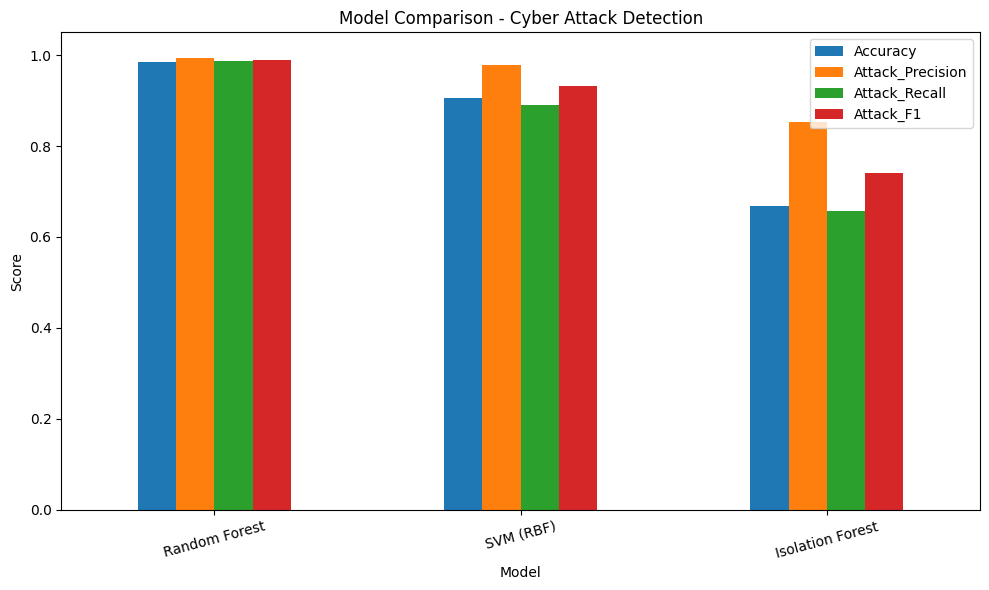

Saved figure: D:\VU project CS619\ML based Cyber Attack Detection\ML model training\next-level experiment model training\outputs\figures\model_comparison_v1.png


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# -----------------------------
# 1. Collect predictions
# Assumes these already exist:
# y_test2, pred2              -> Random Forest test result
# y_test_svm, svm_pred        -> SVM test result
# y_iforest_all, iforest_pred -> Isolation Forest result
# -----------------------------

def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1
    )
    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Attack_Precision": round(p, 4),
        "Attack_Recall": round(r, 4),
        "Attack_F1": round(f1, 4)
    }

comparison_rows = [
    get_metrics(y_test2, pred2, "Random Forest"),
    get_metrics(y_test_svm, svm_pred, "SVM (RBF)"),
    get_metrics(y_iforest_all, iforest_pred, "Isolation Forest")
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(by="Attack_F1", ascending=False).reset_index(drop=True)

print(comparison_df)

# -----------------------------
# 2. Save CSV
# -----------------------------
csv_path = BASE_DIR / "models/comparison_reports/model_comparison_v1.csv"
comparison_df.to_csv(csv_path, index=False)
print("\nSaved CSV:", csv_path)

# -----------------------------
# 3. Save bar chart
# -----------------------------
plot_df = comparison_df.set_index("Model")[["Accuracy", "Attack_Precision", "Attack_Recall", "Attack_F1"]]

ax = plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison - Cyber Attack Detection")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.tight_layout()

fig_path = BASE_DIR / "outputs/figures/model_comparison_v1.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved figure:", fig_path)